Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


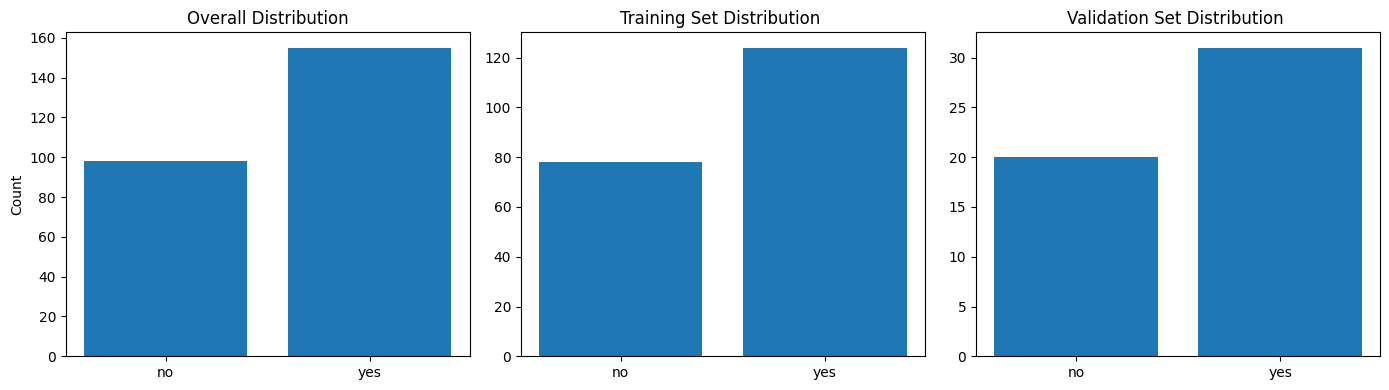

Saved to: /content/drive/MyDrive/fig_class_dist_seed0_fold0.png
Class order: ['no', 'yes']
Overall counts: [ 98 155] Total: 253
Train counts: [ 78 124] Total: 202
Val counts: [20 31] Total: 51


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

# =========================
# Plot class distribution for 5-fold CV (one chosen fold)
# =========================
import numpy as np
import matplotlib.pyplot as plt
from torchvision import datasets
from sklearn.model_selection import StratifiedKFold
from pathlib import Path

DATA_DIR = "/content/drive/MyDrive/brain_tumor_data_set" 
SEED = 0
K_FOLDS = 5
FOLD_ID = 0  


ds = datasets.ImageFolder(DATA_DIR)
targets = np.array(ds.targets)              
idx_to_class = {v: k for k, v in ds.class_to_idx.items()}  


skf = StratifiedKFold(n_splits=K_FOLDS, shuffle=True, random_state=SEED)
splits = list(skf.split(np.zeros_like(targets), targets))
train_idx, val_idx = splits[FOLD_ID]

def count_by_class(indices, targets, idx_to_class):
    y = targets[indices]
    counts = np.bincount(y, minlength=len(idx_to_class))
    labels = [idx_to_class[i] for i in range(len(idx_to_class))]
    return labels, counts


labels_all, counts_all = count_by_class(np.arange(len(targets)), targets, idx_to_class)
labels_tr , counts_tr  = count_by_class(train_idx, targets, idx_to_class)
labels_va , counts_va  = count_by_class(val_idx, targets, idx_to_class)


plt.figure(figsize=(14,4))

ax1 = plt.subplot(1,3,1)
ax1.bar(labels_all, counts_all)
ax1.set_title("Overall Distribution")
ax1.set_ylabel("Count")

ax2 = plt.subplot(1,3,2)
ax2.bar(labels_tr, counts_tr)
ax2.set_title(f"Training Set Distribution ")

ax3 = plt.subplot(1,3,3)
ax3.bar(labels_va, counts_va)
ax3.set_title(f"Validation Set Distribution ")

plt.tight_layout()


out_path = Path("/content/drive/MyDrive") / f"fig_class_dist_seed{SEED}_fold{FOLD_ID}.png"
plt.savefig(out_path, dpi=300, bbox_inches="tight")
plt.show()

print("Saved to:", out_path)
print("Class order:", labels_all)
print("Overall counts:", counts_all, "Total:", counts_all.sum())
print("Train counts:", counts_tr, "Total:", counts_tr.sum())
print("Val counts:", counts_va, "Total:", counts_va.sum())
